In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv('../../course_assignments/homework9/solar_system.csv')

In [5]:
#4
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nFirst 5 Rows:")
print(df.head(5))

print("\nLast 5 Rows:")
print(df.tail(5))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nRow Names (Index):")
print(df.index.tolist())

Shape: (20, 11)
Rows: 20, Columns: 11

First 5 Rows:
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  

Last 5 Rows:
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0   

In [13]:
#5
orbital_period = df.iloc[10, 1:].astype(float)  
perihelion = df.iloc[8, 1:].astype(float)     
aphelion = df.iloc[9, 1:].astype(float)     

In [15]:
#6
print("Perihelion is the specific point in a planet's orbit where it is physically closest to the Sun. Since orbits are ellipses, this is the shorter side of the path.")
print("\nAphelion is the point in the orbit where the planet is farthest away from the Sun, which occurs at the opposite end of the ellipse from the perihelion.")
print("\nThe Semi-major axis is half of the longest diameter of the elliptical orbit, like the average distance between the planet and the Sun.")

Perihelion is the specific point in a planet's orbit where it is physically closest to the Sun. Since orbits are ellipses, this is the shorter side of the path.

Aphelion is the point in the orbit where the planet is farthest away from the Sun, which occurs at the opposite end of the ellipse from the perihelion.

The Semi-major axis is half of the longest diameter of the elliptical orbit, like the average distance between the planet and the Sun.


New shape: (22, 11)
Number of rows: 22
Number of columns: 11


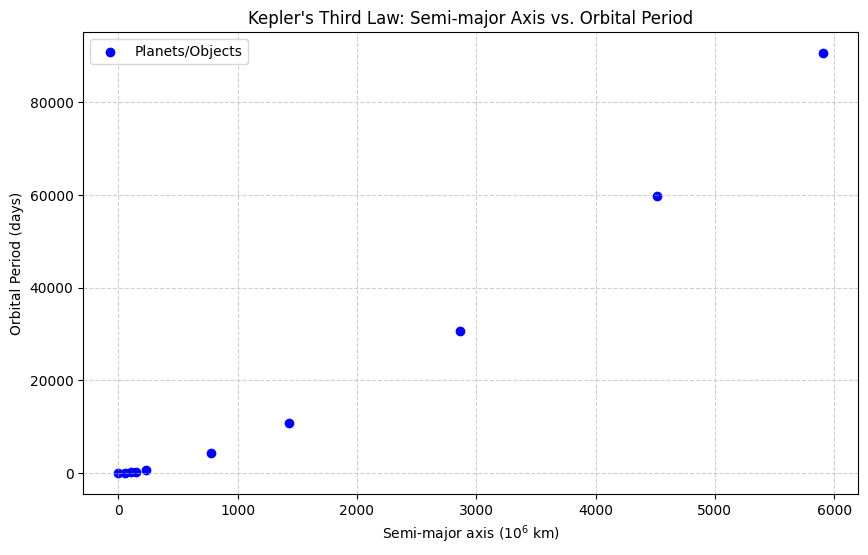

In [17]:
#7
semi_major_axis = (perihelion + aphelion) / 2

#8
new_row_dict = {"Attribute": "Semi-major axis (10^6 km)"}
new_row_dict.update(semi_major_axis.to_dict())

new_row_df = pd.DataFrame([new_row_dict])

df = pd.concat([df, new_row_df], ignore_index=True)

#9
print(f"New shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

#10 
plt.figure(figsize=(10, 6))

plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets/Objects')

plt.xlabel('Semi-major axis ($10^6$ km)')
plt.ylabel('Orbital Period (days)')
plt.title('Kepler\'s Third Law: Semi-major Axis vs. Orbital Period')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [18]:
#11
def keplers_third_law(a, m):
    return m * a ** 1.5

#12
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)

#13
m_fit = popt[0]

#14
print(f"Fitted Model: T = {m_fit:.2f} * a^1.5")

#15
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(orbital_period) - len(popt)
chi2_red = chi2 / dof

print(f"Reduced Chi-Squared: {chi2_red:.2f}")

Fitted Model: T = 0.20 * a^1.5
Reduced Chi-Squared: 41276.71


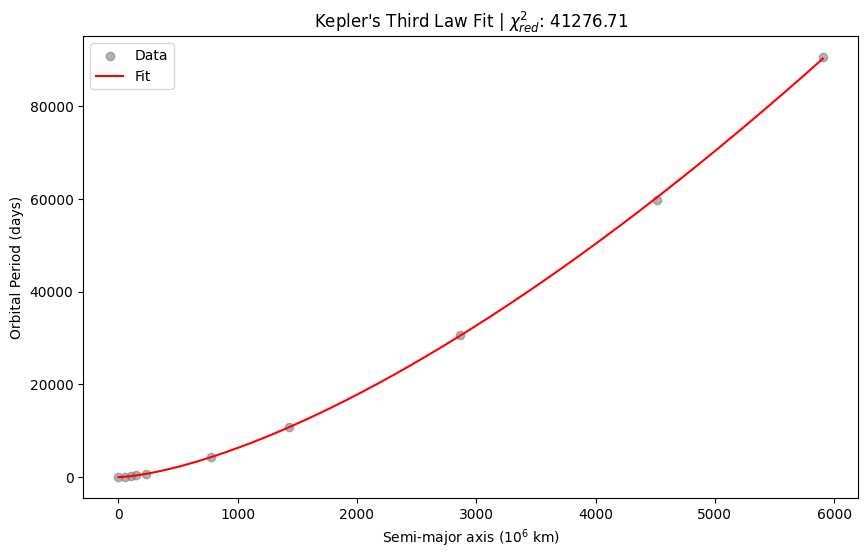

In [19]:
#16
plt.figure(figsize=(10, 6))

plt.scatter(semi_major_axis, orbital_period, color='gray', alpha=0.6, label='Data')

a_smooth = np.linspace(semi_major_axis.min(), semi_major_axis.max(), 500)
plt.plot(a_smooth, keplers_third_law(a_smooth, m_fit), color='red', label='Fit')

plt.title(rf"Kepler's Third Law Fit | $\chi^2_{{red}}$: {chi2_red:.2f}")
plt.xlabel('Semi-major axis ($10^6$ km)')
plt.ylabel('Orbital Period (days)')
plt.legend()

plt.show()

In [21]:
df.to_csv("kepler.csv", index=False)